## 9.1 正则化 - 随机失活（dropout）

#### 1. 什么是正则化（Regularization）
在我们之前学习 机器学习（线性回归） 时，其实已经接触过正则化。

例如：

线性回归中的损失函数

![Loss = MSE + 1 • w2.png](<attachment:Loss = MSE + 1 • w2.png>)
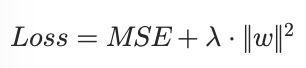

##### 1.1 正则化的本质
正则化的核心思想是：
* 在优化目标中加入“约束”
* 防止模型过于复杂

也就是说：
* 不仅要拟合数据
* 还要限制模型的自由度

#### 1.2 为什么需要正则化
如果没有正则化：
* 模型在训练集表现很好
* 但在测试集表现很差

这就是：
* 过拟合（Overfitting）

##### 1.3 正则化的目标
正则化的核心目标是：
* 让模型更泛化
* 减少过拟合

##### 1.4 常见正则化方法（回顾）
在机器学习中我们已经学过：
```
方法	本质
L1 正则化	限制参数绝对值
L2 正则化	限制参数平方
Early Stopping	提前停止训练
```

#### 2. L1 L2正则化的效果

##### 2.1 L1正则化(Lasso)

🔹（1）损失函数

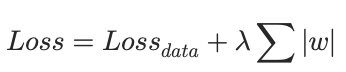

🔹（2）梯度计算

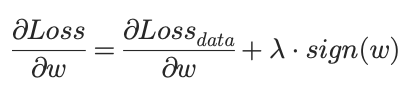

其中：
```
sign(w) =
+1（w > 0）
-1（w < 0）
```

🔹（3）参数更新公式

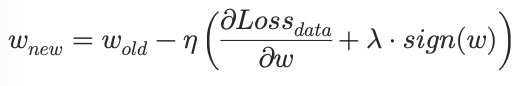

🔹（4）拆解理解（非常重要）
可以拆成两部分：
* ① 原始梯度更新
* ② L1 的“恒定推力”

即：
```
w_new = w_old
        - η * 原始梯度
        - ηλ * sign(w)
```
* L1 的“恒定推力”： 不管 w 目前是多少（只要不是 0），L1 都会给它施加一个恒定的力 λ，把它推向 0。


##### 2.2 L2 正则化（Ridge / Weight Decay） 

🔹（1）损失函数

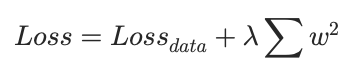

🔹（2）梯度计算

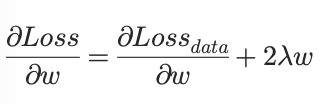

🔹（3）参数更新公式

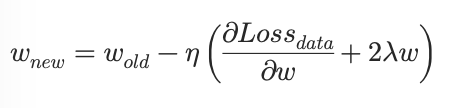

🔹（4）整理成“衰减形式”（重点！）

展开：

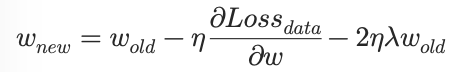

整理：

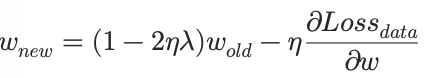

🔥 核心理解（重点记）
* L2 = 先把 w 缩小（乘一个 <1 的系数）
* 再做梯度更新


#### 3. 神经网络中的正则化
在深度学习中，由于：
* 模型更复杂
* 参数更多

过拟合问题更加严重。

因此提出了更多正则化方法：
```
Dropout（随机失活）
BatchNorm（间接正则化）
数据增强（Data Augmentation）
```
其中最经典的就是：

`Dropout`

#### 4. 什么是 Dropout
Dropout 的核心思想是：

在训练过程中，随机“关闭”一部分神经元，从而限制模型能力。

也就是说：
* 每一次前向传播
* 随机丢弃一部分神经元


##### 4.1 直观理解
原始网络：

`○ ○ ○ ○ ○ ○`

Dropout 后：

`○ ✖ ○ ✖ ○ ✖`

其中：

`✖ = 被随机关闭的神经元`


##### 4.2 Dropout 为什么是正则化
这是这一节最重要的一点：

`Dropout 本质上是在限制模型复杂度`

具体来说：

（1）减少模型容量
* 每次训练只使用部分神经元
* 相当于一个更小的模型在训练

（2）打破神经元依赖关系
* 如果没有 Dropout：
    * 某些神经元会互相依赖（共适应）
* 使用 Dropout：
    * 这些依赖被打断
* 这使得模型必须学习更关键的特征

（3）等价于模型集成（Ensemble）
* Dropout 可以理解为：训练了大量不同的子网络
* 测试时相当于：对这些子模型取平均

##### 4.3 Dropout 的核心参数
Dropout 使用一个参数：

`p（dropout rate）`

表示：
* 神经元被丢弃的概率

例如：
```
p	含义
0.5	50% 神经元被关闭
0.2	20% 被关闭
```

#### 5. 常见参数设置
**1️⃣ 常见的 p 取值**

最常见的取值范围：

`0.2 ~ 0.5`

常见经验：
* p = 0.5：经典、常见
* p = 0.3：比较温和
* p = 0.2：较轻的正则化

**2️⃣ p 太大会怎么样**

如果：

`p = 0.8`

表示：
* 80% 神经元都被丢弃

这会导致：
* 模型学不到足够信息
* 训练变得很困难

**3️⃣ p 太小会怎么样**

如果：

`p = 0.05`

表示：
* 只有 5% 被丢弃
* 那正则化效果可能不明显。

#### 6. Dropout 的数学形式

![Pasted Graphic 5.png](<attachment:Pasted Graphic 5.png>)

假设某一层输出是：

`h = [2, 4, 6, 8] # 4个神经元`

现在我们设置：

`p = 0.5（50% 概率丢弃）`
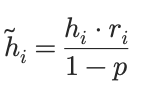

##### 6.1 第一步：生成随机 mask（关键！）
Dropout 会生成一个“开关向量”：

`r = [1, 0, 1, 0]`

含义：
```
值	含义
1	保留这个神经元
0	关闭这个神经元
```

##### 6.2 第二步：逐元素相乘（丢弃神经元）

`h * r = [2, 0, 6, 0]`

👉 这一步就是：随机关闭神经元

##### 6.3 第三步：缩放处理
为什么还要除以 (1-p)？

**❗️如果不做缩放**

原始平均值：

`mean(h) = (2+4+6+8)/4 = 5`

Dropout 后：

```
[2, 0, 6, 0]
mean = 2
```

👉 问题：

数值整体变小了！

✅ 解决方法：补偿（Scaling）

因为我们只保留了：

`1-p = 0.5 的神经元`

所以我们需要：

`除以 0.5（= 乘以 2）`

所以缩放后：

`[2, 0, 6, 0] / 0.5 = [4, 0, 12, 0]`

👉 现在期望值恢复正常

##### 6.4 ❓为什么要保持期望不变（核心理解）
因为：
* 👉 训练时用了 Dropout
* 👉 测试时不用 Dropout

如果不缩放：
* 训练输出 ≠ 测试输出

会导致：
* 模型不稳定

#### 7. 训练 vs 测试
**🔥 Inverted Dropout 的思想**

现在主流做法是：
* 训练时就做缩放
* 测试时什么都不用做

**1️⃣ 训练阶段**

随机丢弃神经元

**2️⃣ 测试阶段**

不丢弃神经元

直接使用完整网络